# Write a Python Program to demonstrate image data augmentation techniques

In [32]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [33]:
(train_ds, val_ds, test_ds), metadata = tfds.load(
    "tf_flowers",
    split=["train[:80%]", "train[80%:100%]", "train[90%:]"],
    with_info = True,
    as_supervised = True,
)

In [34]:
def preprocess_image(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    return tf.cast(image, tf.uint8), label

In [35]:
def mapper(ds):
    return ds.map(preprocess_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)

In [36]:
train_ds, val_ds, test_ds = mapper(train_ds), mapper(val_ds), mapper(test_ds)

In [37]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [47]:
def plot_images(original, augmented):
    plt.figure(figsize=(10, 5))

    for i in range(len(original)):
        plt.subplot(2, len(original), i+1)
        plt.imshow(original[i])
        plt.title("Original")
        plt.axis('off')

        plt.subplot(2, len(original), i+1+len(original))
        plt.imshow(augmented[i])
        plt.title("Augmented")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [48]:
num_images = 5
sample_images = []

for image, _ in train_ds.take(num_images):
    sample_images.append(image.numpy())

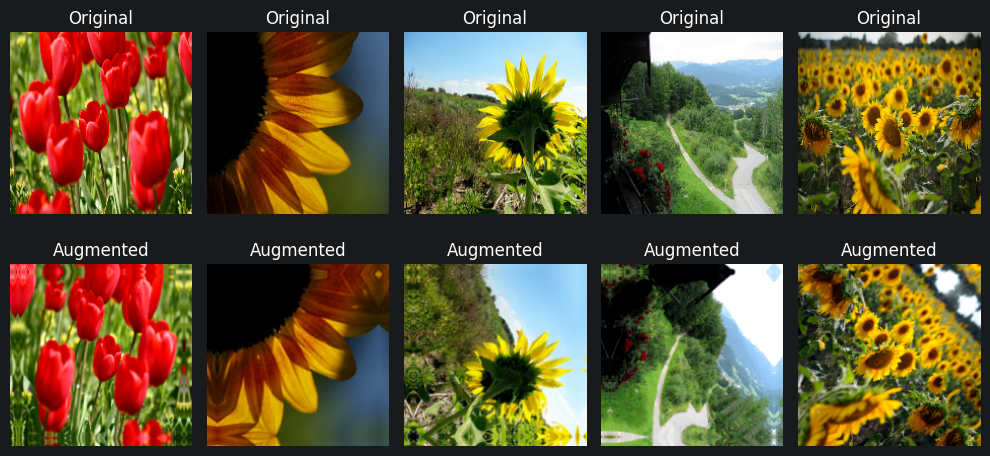

In [49]:
sample_batch = tf.stack(sample_images)
augmented_batch = data_augmentation(sample_batch)

plot_images(sample_images, tf.cast(augmented_batch, tf.uint8).numpy())